# Tutorial 03 — Gasificador 0D: Gasificación con agente externo (CSTR)

**Equipo:** Gasificador de lecho fijo · **Modo:** 0D (N=1) · CSTR (flujo continuo de gas)  
**Fenómeno:** Pirólisis + reacciones de char con agente gasificante (aire/vapor/CO₂)  
**Prerrequisito:** Tutorial 02 — Gasificador 0D Semibatch

## Introducción

Este tutorial introduce el **modo CSTR**: un agente gasificante fluye continuamente
a través del lecho (v_gas_in > 0), mientras el sólido permanece estático (v_solid = 0).
La salida del gas se calcula por **continuidad molar** (v_out = None).

### Diferencia fundamental respecto a los tutoriales anteriores

| Parámetro | Batch (01) | Semibatch (02) | CSTR (este tutorial) |
|-----------|------------|----------------|----------------------|
| _gas_in | None | None | > 0 — agente gasificante |
| _out |  .0 (sellado) | > 0 (venteo) | None — continuidad molar |
| Flujo en balance | 0 | ≠ 0 (solo salida) | ≠ 0 (entrada y salida) |
| Fh_conv_neto | 0 | ≠ 0 | ≠ 0 |

### Secuencia de fenómenos

Con agente gasificante a alta temperatura (600 K) y pared caliente (1037 K):

1. **Calentamiento** — la pared y el gas caliente elevan Ts; drying arranca ~100 °C
2. **Secado** — H₂O evaporada; pico de H₂O en el gas
3. **Pirólisis** — char + CO/CO₂/H₂/CH₄/tar producidos conforme Ts > 400 °C
4. **Reacciones de char** — O₂ del aire oxida el char (exotérmica); CO₂ y H₂O reaccionan con el char restante (endotérmicas: Boudouard, water-gas)

### Tres agentes gasificantes comparados (sección 11)

| Agente | Composición molar | Reacción dominante | Gas producido |
|--------|-------------------|--------------------|---------------|
| Aire | 21 % O₂ + 79 % N₂ | Char + O₂ (oxidación) | CO₂/CO + N₂ diluido |
| Vapor | 100 % H₂O | Char + H₂O → CO + H₂ (water-gas) | Syngas limpio |
| Aire+vapor | 21 % O₂ + 21 % H₂O + 58 % N₂ | Oxidación parcial + water-gas | Syngas + calor propio |

In [30]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.io.fuels_reader import read_fueldb
from src.units.gasifier.config.gas_props    import build_gas_prop_config, GASIFIER_GAS_SPECIES
from src.units.gasifier.config.solid_props  import build_solid_prop_config
from src.units.gasifier.config.transport    import build_transport_config
from src.units.gasifier.config.thermal_bc   import build_thermal_bc_config
from src.units.gasifier.config.boundary_c   import build_bc_config
from src.units.gasifier.config.initial_c    import build_initial_c_config
from src.solvers.runner_gasifier            import run_step
from src.postprocessing.gasifier_balances   import check_balances, display_balances
from src.postprocessing.gasifier_plots      import (
    plot_temperatures, plot_solid_evolution,
    plot_gas_composition, plot_pressure,
    plot_velocities, plot_summary,
)

print(f"ROOT: {ROOT}")

ROOT: C:\Users\MiguelCamaraSanz\OneDrive - Fundacion CIRCE\GITHUB\ProSimNet-gasifier


## 1. Bases de datos y combustible

In [31]:
FUEL_PATH = os.path.join(ROOT, "materials", "fuels", "softwood_spruce.yaml")
GAS_DB    = os.path.join(ROOT, "materials", "fluids", "gasdb.txt")
SOLID_DB  = os.path.join(ROOT, "materials", "solids", "soliddb.txt")

fuel_config = read_fueldb(FUEL_PATH)
rho_p = float(fuel_config["physical"]["rho_particle"])
dp0   = float(fuel_config["physical"]["dp_initial"])
print(f"Combustible : {fuel_config['description']}")
print(f"rho_p = {rho_p:.0f} kg/m3   dp0 = {dp0*1e3:.1f} mm")

Combustible : Softwood (spruce) for fixed-bed updraft gasification
rho_p = 430 kg/m3   dp0 = 10.0 mm


## 2. Geometría y condiciones de operación

Mismo reactor que los tutoriales anteriores (≈ 785 cm³, Di = 10 cm, L = 10 cm).

In [32]:
# ── Geometría ─────────────────────────────────────────────────────────────────
N  = 1       # Número de celdas → modelo 0D (volumen perfectamente mezclado)
L  = 0.10    # [m]  longitud del reactor
Di = 0.10    # [m]  diámetro interno
Do = 0.114   # [m]  diámetro externo (e_pared = 7 mm, acero inox 316L)

dz     = L / N                     # [m]   tamaño de celda
Ai     = 0.25 * np.pi * Di**2      # [m²]  sección transversal interna
Pi     = np.pi * Di                # [m]   perímetro interno
Po     = np.pi * Do                # [m]   perímetro externo
e_wall = (Do - Di) / 2             # [m]   espesor de pared

# ── Condiciones de operación ──────────────────────────────────────────────────
epsi_r = 0.60       # [-]   porosidad del lecho (fracción de huecos gas/volumen lecho)
P_out  = 1.01325    # [bar] presión de salida (atmósfera)

# ── Carga inicial de biomasa ──────────────────────────────────────────────────
mc_wb       = 0.15                                          # [-]         contenido de humedad base húmeda
rho_bio_dry = rho_p * (1 - epsi_r)                          # [kg/m³_bed] biomasa seca en lecho
rho_moi_0   = rho_bio_dry * mc_wb / (1 - mc_wb)             # [kg/m³_bed] humedad inicial
rho_bio_0   = rho_bio_dry                                   # [kg/m³_bed] biomasa inicial
rho_char_0  = 1e-6                                          # [kg/m³_bed] traza de char inicial

# Densidad de referencia del char (para modelo de partícula decreciente SCM)
rho_char0 = fuel_config["pyrolysis_yields"]["char"] * rho_p * (1 - epsi_r)

print(f"Geometría:")
print(f"  N = {N} celdas → modelo 0D")
print(f"  V_reactor = {Ai*L*1e6:.1f} cm³  (Di={Di*100:.0f} cm, L={L*100:.0f} cm)")
print(f"\nCarga inicial de sólido:")
print(f"  ρ_biomasa  = {rho_bio_0:.1f} kg/m³_bed")
print(f"  ρ_humedad  = {rho_moi_0:.1f} kg/m³_bed  ({mc_wb*100:.0f} % wb)")
print(f"  ρ_char_ini = {rho_char_0:.1e} kg/m³_bed  (traza)")

Geometría:
  N = 1 celdas → modelo 0D
  V_reactor = 785.4 cm³  (Di=10 cm, L=10 cm)

Carga inicial de sólido:
  ρ_biomasa  = 172.0 kg/m³_bed
  ρ_humedad  = 30.4 kg/m³_bed  (15 % wb)
  ρ_char_ini = 1.0e-06 kg/m³_bed  (traza)


## 3. Condiciones iniciales del gas

El lecho empieza lleno de N₂ inerte a temperatura ambiente (igual que en los casos anteriores).
El agente gasificante entra a través de la condición de contorno de entrada.

In [33]:
T_init = 300.0   # [K]  temperatura inicial gas y sólido

species = list(GASIFIER_GAS_SPECIES)
nc      = len(species)

y0 = np.zeros(nc)
y0[species.index("N2")] = 1.0

print(f"CI gas: 100 % N2  T={T_init:.0f} K  P={P_out:.5f} bar")

CI gas: 100 % N2  T=300 K  P=1.01325 bar


## 4. Condiciones de contorno

### Modo CSTR: flujo continuo de agente gasificante

_gas_in = 0.01 m/s — velocidad superficial del gas de entrada (aire precalentado a 600 K).  
_out = None — velocidad de salida calculada por **continuidad molar**:
{out}(t) = v_{in} \cdot \frac{C_{tot,in}}{C_{tot,out}}$

En modo CSTR con reacciones, la continuidad molar no garantiza presión constante.
Las reacciones producen gas (Ctot sube) → v_out baja respecto a v_in → P puede subir.
Para operación isobara usar v_out > 0 (venteo activo) o Cv > 0 (válvula ISA).

### Agente gasificante: AIRE

Composición molar: 21 % O₂ + 79 % N₂ (aire seco).  
Temperatura de entrada: 600 K (precalentado) — aporta entalpía al lecho.

In [39]:
V_IN  = 0.01    # [m/s]  velocidad superficial del agente gasificante
T_IN  = 600.0   # [K]    temperatura de entrada (aire precalentado a 327 °C)

y_air = np.zeros(nc)
y_air[species.index("O2")] = 0.21
y_air[species.index("N2")] = 0.79

bc_cfg = build_bc_config(
    n_comp    = nc,
    P_out_bar = P_out,
    v_gas_in  = V_IN,
    T_gas_in  = T_IN,
    y_gas_in  = y_air,
    v_out     = None,    # continuidad molar
)

T_wall   = 1073.15   # [K] = 800 °C
k_wall   = 16.5;  rho_wall = 7950.0;  Cp_wall = 510.0

tbc_cfg = build_thermal_bc_config(
    mode="fixed_twall", Di=Di, Do=Do, e_wall=e_wall,
    T_wall=T_wall, k_wall=k_wall, rho_wall=rho_wall, Cp_wall=Cp_wall,
)

print(f"BC gas   : CSTR  v_in={V_IN} m/s  T_in={T_IN:.0f} K  y_O2={y_air[species.index('O2')]:.2f}")
print(f"BC térmica: T_wall={T_wall:.2f} K ({T_wall-273.15:.0f} °C)")

BC gas   : CSTR  v_in=0.01 m/s  T_in=600 K  y_O2=0.21
BC térmica: T_wall=1073.15 K (800 °C)


## 5. Propiedades y modelo de transporte

In [40]:
prop_gas     = build_gas_prop_config(fuel_config=fuel_config, mode="polynomial", db_path=GAS_DB)
gas_T_ref    = float(np.min(np.asarray(prop_gas["Tref"])))
MW_arr       = np.asarray(prop_gas["MW"])
solid_config = build_solid_prop_config(fuel_config)
trans_cfg    = build_transport_config(
    mode="constant", N=N, n_comp=nc, h_bed=80.0, h_wall=20.0,
)
print(f"gas_T_ref = {gas_T_ref:.2f} K   transporte: constante (h_bed=80, h_wall=20 W/m2/K)")

gas_T_ref = 298.00 K   transporte: constante (h_bed=80, h_wall=20 W/m2/K)


## 6. Vector de estado inicial (sv0)

El vector de estado `sv0` codifica el estado completo del sistema para el integrador ODE.
Para un gasificador sin modelo dinámico de pared y con N celdas:

```
sv0 = [C(nc×N), ρ_s(3×N), Hg(N), Ts(N), Q_mt_acc(N), Q_rxn_acc(N), Q_gs_acc(N)]
      └── 9N ──┘└── 3N ──┘└─ N ┘└─ N ┘└────── N ─────┘└────── N ──┘└────── N ──┘
                                                                    total = 17×N
```

Para N=1: `sv0.shape = (17,)`

In [41]:
init_cfg = build_initial_c_config(
    P_init            = P_out,
    Tg_init           = T_init,
    Ts_init           = T_init,
    y_init            = y0,
    rho_biomass_init  = rho_bio_0,
    rho_char_init     = rho_char_0,
    rho_moisture_init = rho_moi_0,
    n_comp            = nc,
    N                 = N,
    prop_gas          = prop_gas,
    epsi_r            = epsi_r,
    gas_T_ref         = gas_T_ref,
    Tw_init           = None,    # Sin modelo dinámico de pared
)

sv0 = init_cfg["sv0"]
print(f"sv0.shape = {sv0.shape}   ({sv0.shape[0] // N} × {N} = {sv0.shape[0]} DOFs)")

sv0.shape = (17,)   (17 × 1 = 17 DOFs)


## 7. Diccionario de parámetros

El diccionario `params` contiene todos los parámetros del modelo.
Para los estudios paramétricos (sección 11) se usa `params_base` sin `bc_config`,
que se añade por separado en cada caso (mismo patrón que en el Tutorial 02).

In [42]:
params_base = {
    # Geometría
    "n_comp" : nc,
    "N"      : N,
    "dz"     : dz,
    "Ai"     : Ai,
    "Di"     : Di,
    "Pi"     : Pi,
    "Po"     : Po,
    # Propiedades del gas
    "prop_gas"   : prop_gas,
    "MW"         : MW_arr,
    "gas_T_ref"  : gas_T_ref,
    # Configuraciones compartidas
    "trans_config"     : trans_cfg,
    "thermal_bc_config": tbc_cfg,
    "energy"           : True,
    # Específico del gasificador
    "epsi_r"      : epsi_r,
    "dp0"         : dp0,
    "rho_char0"   : rho_char0,
    "fuel_config" : fuel_config,
    "solid_config": solid_config,
    "species"     : species,
    # bc_config se añade en cada caso (run principal + paramétricos)
}

# Caso principal: aire como agente gasificante
params = {**params_base, "bc_config": bc_cfg}

## 8. Simulación

In [43]:
T_MAX = 600.0   # [s]

print("=" * 60)
print(f"Simulando: Gasificador 0D CSTR — Aire {T_MAX:.0f} s")
print("=" * 60)

t_arr, y_hist, gasifier = run_step(
    sv0=sv0, t_max=T_MAX, params=params,
    rtol=1e-5, atol=1e-7, n_sec=5, show_progress=True,
)

if t_arr[-1] < T_MAX * 0.99:
    print(f"\n⚠  Solver no alcanzó t_max. t_final = {t_arr[-1]:.1f} s")
else:
    print(f"\n✓  Completado. t_final = {t_arr[-1]:.1f} s  |  pasos = {len(t_arr)}")
    print(f"   Tg_final = {gasifier._Tg_results[-1,0]:.1f} K  ({gasifier._Tg_results[-1,0]-273.15:.1f} °C)")
    print(f"   Ts_final = {gasifier._Ts_results[-1,0]:.1f} K  ({gasifier._Ts_results[-1,0]-273.15:.1f} °C)")
    print(f"   v_out_final = {gasifier._v_out_results[-1]:.4f} m/s  (v_in = {V_IN} m/s)")
    rho_bio_f = gasifier._rho_solid_results[-1, 0, 0]
    rho_chr_f = gasifier._rho_solid_results[-1, 1, 0]
    print(f"   rho_bio_final = {rho_bio_f:.2f} kg/m3_bed  rho_char_final = {rho_chr_f:.2f} kg/m3_bed")

Simulando: Gasificador 0D CSTR — Aire 600 s


gasifier:   0%|          | 0.0/600 s [00:00<?, ?s/s]


✓  Completado. t_final = 600.0 s  |  pasos = 3001
   Tg_final = 638.0 K  (364.9 °C)
   Ts_final = 640.9 K  (367.8 °C)
   v_out_final = 0.0106 m/s  (v_in = 0.01 m/s)
   rho_bio_final = 105.92 kg/m3_bed  rho_char_final = 11.24 kg/m3_bed


## 9. Resultados — dashboard completo

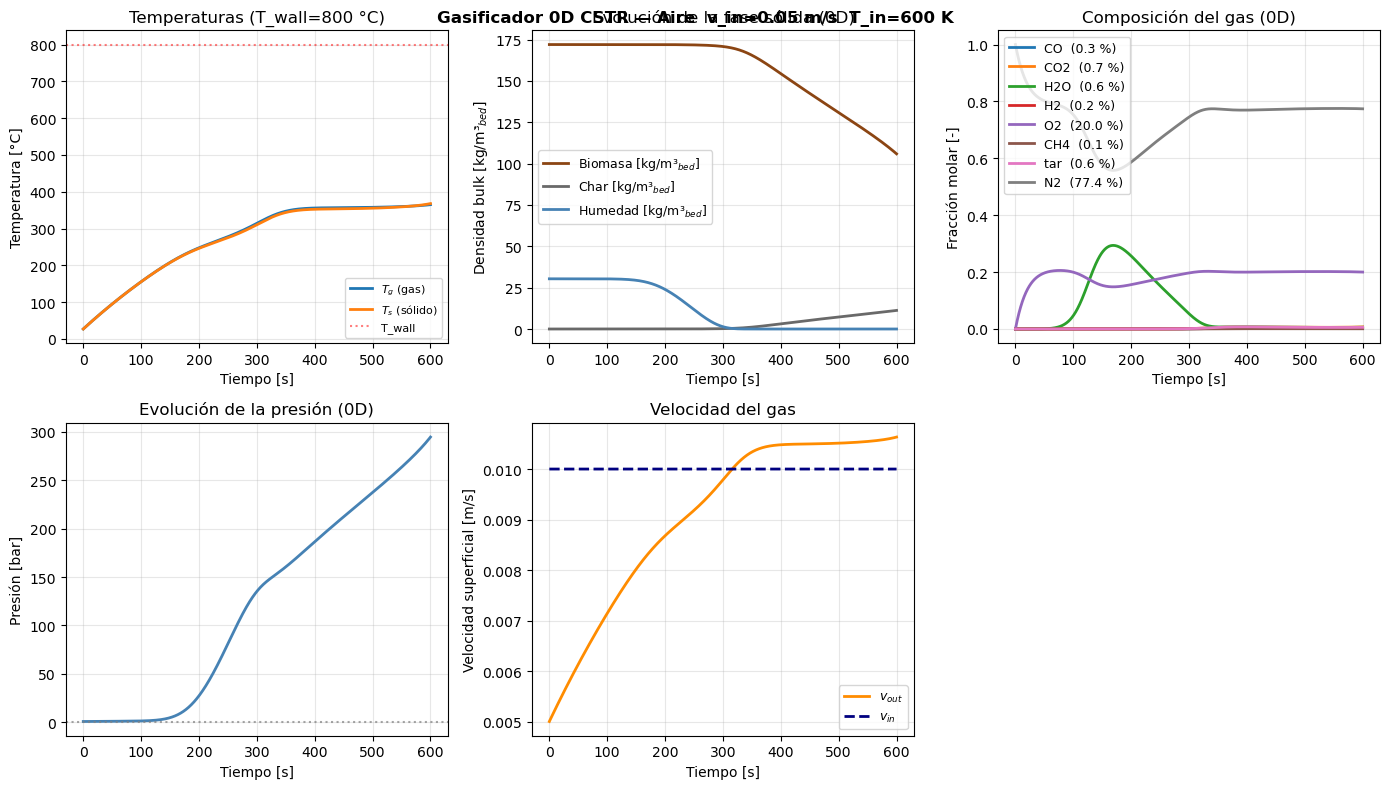

In [44]:
fig, axes = plot_summary(gasifier)
axes[0, 0].set_title(f"Temperaturas (T_wall={T_wall-273.15:.0f} °C)")
axes[0, 0].axhline(T_wall - 273.15, ls=":", color="red", alpha=0.5, label="T_wall")
axes[0, 0].legend(fontsize=8)
axes[1, 0].axhline(P_out, ls=":", color="gray", alpha=0.7)
fig.suptitle("Gasificador 0D CSTR — Aire  v_in=0.05 m/s  T_in=600 K", fontweight="bold")
plt.show()

### Detalle por variable

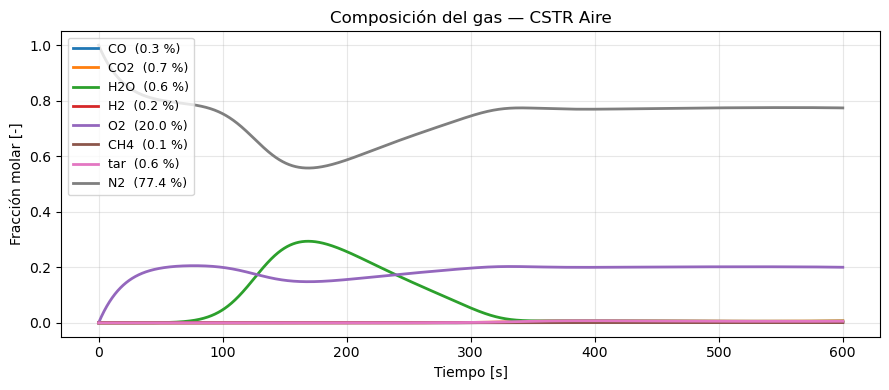

In [45]:
fig, ax = plot_gas_composition(gasifier)
ax.set_title("Composición del gas — CSTR Aire")
plt.show()

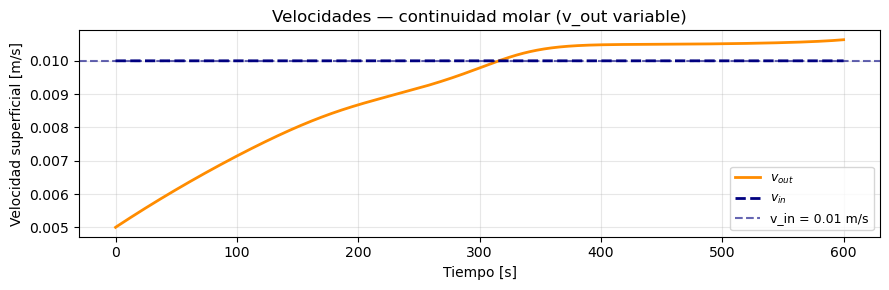

In [46]:
fig, ax = plot_velocities(gasifier)
ax.axhline(V_IN, ls="--", color="navy", alpha=0.6, label=f"v_in = {V_IN} m/s")
ax.set_title("Velocidades — continuidad molar (v_out variable)")
ax.legend(fontsize=9)
plt.show()

---
## 10. Verificación de balances

En CSTR, Flujo_masa_neto ≠ 0 y Fh_conv_neto ≠ 0 porque el gas entra y sale.
La columna Flujo [mol|kg/m³] de la tabla de especies ya no es cero para ninguna especie.

In [29]:
balances = check_balances(gasifier, params, verbose=False)
display_balances(balances)

── ★ Masa total [kg/m³] ──────────────────────────────────────────────


,Valor [kg/m³],Tipo
Término,,
Δm_gas,+7.5871e+01,
Δm_sólido,-6.2046e+01,
Flujo_masa_neto,+1.3823e+01,
★ Cierre,+1.8948e-03,0.002 % ✓ OK



── ~ Especies gas [mol/m³ | kg/m³]  (Fuente_rxn ≠ 0 esperado — residual físico; ★ Cierre ≈ 0) ─
   Formato: mol/m³  /  kg/m³  |  TOTAL kg/m³ ≈ Δm_gas del balance de masa  |  ★ Cierre ≈ 0 por construcción


,ΔC [mol | kg/m³],Flujo [mol | kg/m³],~ Fuente_rxn [mol | kg/m³],★ Cierre [mol | kg/m³]
CO,+5.639e-01 / +1.580e-02,-1.204e+02 / -3.371e+00,+1.209e+02 / +3.387e+00,-1.421e-14 / +0.000e+00
CO2,+1.193e+00 / +5.251e-02,-2.535e+02 / -1.115e+01,+2.547e+02 / +1.121e+01,+0.000e+00 / +1.776e-15
H2O,+1.284e+00 / +2.313e-02,-1.959e+03 / -3.529e+01,+1.960e+03 / +3.531e+01,+0.000e+00 / +0.000e+00
H2,+5.373e-01 / +1.083e-03,-1.148e+02 / -2.314e-01,+1.153e+02 / +2.325e-01,+1.421e-14 / +2.776e-17
O2,+5.554e+02 / +1.777e+01,+7.160e+02 / +2.291e+01,-1.606e+02 / -5.138e+00,+0.000e+00 / +0.000e+00
CH4,+1.801e-01 / +2.889e-03,-3.846e+01 / -6.170e-01,+3.864e+01 / +6.199e-01,+0.000e+00 / +0.000e+00
C2H4,+8.366e-02 / +2.347e-03,-1.787e+01 / -5.013e-01,+1.795e+01 / +5.037e-01,+0.000e+00 / -1.110e-16
tar,+1.311e+00 / +7.420e-02,-2.800e+02 / -1.585e+01,+2.813e+02 / +1.592e+01,+0.000e+00 / -1.776e-15
N2,+2.068e+03 / +5.793e+01,+2.068e+03 / +5.793e+01,+5.273e-03 / +1.477e-04,-5.684e-14 / -3.726e-16
── TOTAL ──,+2.628e+03 / +7.587e+01,+4.547e-13 / +1.382e+01,+2.628e+03 / +6.205e+01,-4.547e-13 / +0.000e+00



── ~ Masa sólida [kg/m³]  (S_rxn = masa transformada por reacciones — residual físico esperado ≠ 0) ──────


...

,Valor [J/m³],Nota
Término,,
ΔHg,+4.7284e+07,acumulación gas
Fh_conv_neto,-1.4203e+08,exacto
Q_gs (gas→sólido),+1.9329e+08,acum. ODE — exacto
Q_wall (pared→gas),+2.5258e+08,thermal_bc
Q_mt (sól→gas),+1.2983e+08,acum. ODE — exacto
★ Cierre_Hg,+2.0553e+05,0.081 % ✓ OK



── ★ Energía sólido  Ts [J/m³] ──────────────────────────────────────────


,Valor [J/m³],Nota
Término,,
"ΔHs [∫Cp dT, exacto]",+7.7120e+07,Σ ρⱼ·H_j(Ts)
Q_gs (gas→sólido),+1.9329e+08,acum. ODE — exacto
Q_rxn (exacto),-1.1617e+08,acum. ODE — exacto
★ Cierre_Hs,+3.8485e+02,0.000 % ✓ OK



── ★ Balance global  Hg+Hs [J/m³] ──────────────────────────────────────


,Valor [J/m³],Nota
Término,,
ΔHg + ΔHs,+1.2440e+08,acumulación total
Fh_conv_neto,-1.4203e+08,exacto
Q_wall,+2.5258e+08,thermal_bc
Q_rxn (exacto),-1.1617e+08,acum. ODE
Q_mt (exacto),+1.2983e+08,acum. ODE
★ Cierre global,+2.0592e+05,0.082 % ✓ OK


## Interpretación de balances

**★ Cierre numérico** — residual debe ser ≈ 0 (umbral: < 1 % del término mayor)  
**~ Residual físico** — residual = cantidad producida o consumida; se espera ≠ 0

### Diferencias respecto al modo Batch/Semibatch

| Balance | Batch/Semibatch | CSTR |
|---------|-----------------|------|
| Flujo [mol\|kg/m³] por especie | ≈ 0 (batch) o solo salida | ≠ 0 para todas las especies |
| ~ Fuente_rxn O₂ | ≥ 0 (no reacciona si no hay char) | < 0 (O₂ consumido por char) |
| ~ Fuente_rxn CO, H₂ | > 0 (pirólisis + gasif.) | > 0 (pirólisis + gasif.) |
| ~ Fuente_rxn N₂ | ≈ 0 (inerte) | ≈ 0 (inerte, solo pasa) |
| ★ Cierre por especie | ≈ 0 | ≈ 0 |
| Fh_conv_neto | 0 (batch) | ≠ 0 (entalpía de entrada y salida) |
| TOTAL kg Fuente_rxn | ≈ \|Δm_sólido\| | puede ser < \|Δm_sólido\| si el O₂ consume char |

### Señales de gasificación activa

- **O₂ negativo** en Fuente_rxn → O₂ consumido por reacciones de char
- **CO y H₂ positivos** con Flujo también positivo → gas producido que sale por outlet
- **v_out < v_in** → la continuidad molar se satisface con menor velocidad de salida
  porque las concentraciones suben (más moles por m³)
- **Fh_conv_neto < 0** (posible) → sale más entalpía de la que entra (lecho caliente)

### Si algún balance ★ no cierra (> 1 %)

- **Masa total > 1 %**: verificar epsi_r en flujos de entrada/salida
- **Energía gas > 1 %**: verificar acumuladores Q_mt y Q_gs en sv
- **Energía sólido > 1 %**: verificar h_fns en solid_config
"@

# ── PARAMÉTRICO ──────────────────────────────────────────────────────────────
                         += mkmd "cell-param-header" @"
---
## 11. Análisis paramétrico

| Estudio | Variable | Valores |
|---------|----------|---------|
| 11.A | _gas_in [m/s] | 0.01, 0.05, 0.10 — ratio aire/combustible |
| 11.B | T_in [K] | 300, 600, 900 — precalentamiento del agente |
| 11.C | Agente | Aire, Vapor (H₂O), Aire+Vapor |

### 11.A — Efecto del caudal de agente (_gas_in)

Más caudal → más O₂ disponible → mayor oxidación del char → Ts más alta.
Menos caudal → régimen gasificación (CO/H₂) vs combustión (CO₂).

  v_in=0.01 m/s — Ts=368 °C  rho_char=11.24 kg/m3
  v_in=0.05 m/s — Ts=333 °C  rho_char=7.05 kg/m3
  v_in=0.1 m/s — Ts=329 °C  rho_char=6.69 kg/m3


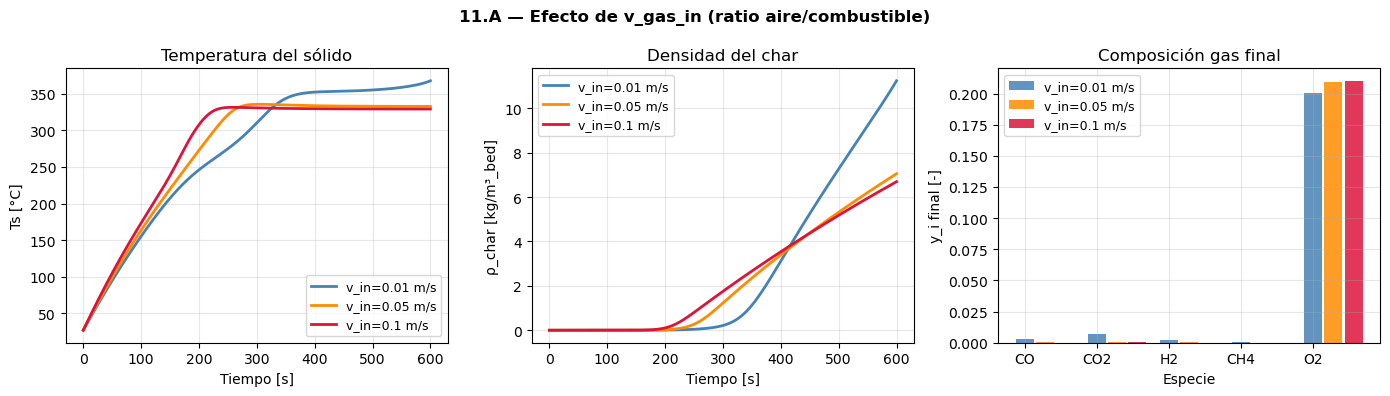

In [47]:
vin_values = [0.01, 0.05, 0.10]
colors_vin = ["steelblue", "darkorange", "crimson"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for vin, col in zip(vin_values, colors_vin):
    bc_v = build_bc_config(n_comp=nc, P_out_bar=P_out,
                           v_gas_in=vin, T_gas_in=T_IN, y_gas_in=y_air)
    par_v = {**params_base, "bc_config": bc_v}
    t_, _, g_ = run_step(sv0=sv0, t_max=T_MAX, params=par_v,
                         rtol=1e-5, atol=1e-7, n_sec=5, show_progress=False)
    lbl = f"v_in={vin} m/s"
    axes[0].plot(t_, g_._Ts_results[:, 0] - 273.15, color=col, lw=2, label=lbl)
    axes[1].plot(t_, g_._rho_solid_results[:, 1, 0], color=col, lw=2, label=lbl)
    y_fin = g_._y_results[-1, :, 0]
    sp_show = ["CO", "CO2", "H2", "CH4", "O2"]
    axes[2].bar([i + vin_values.index(vin)*0.28 for i in range(len(sp_show))],
                [y_fin[species.index(s)] for s in sp_show],
                width=0.25, color=col, label=lbl, alpha=0.85)
    print(f"  v_in={vin} m/s — Ts={g_._Ts_results[-1,0]-273.15:.0f} °C  "
          f"rho_char={g_._rho_solid_results[-1,1,0]:.2f} kg/m3")

axes[0].set(xlabel="Tiempo [s]", ylabel="Ts [°C]", title="Temperatura del sólido")
axes[1].set(xlabel="Tiempo [s]", ylabel="ρ_char [kg/m³_bed]", title="Densidad del char")
axes[2].set(xlabel="Especie", ylabel="y_i final [-]", title="Composición gas final")
axes[2].set_xticks(range(len(sp_show))); axes[2].set_xticklabels(sp_show)
for ax in axes: ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
fig.suptitle("11.A — Efecto de v_gas_in (ratio aire/combustible)", fontweight="bold")
fig.tight_layout(); plt.show()

### 11.B — Efecto del precalentamiento del agente (T_in)

Gas de entrada más caliente → más entalpía disponible para las reacciones.
¿Cuánto afecta T_in al perfil de Ts y a la composición del syngas?

  T_in=300 K — Ts_final=172 °C
  T_in=600 K — Ts_final=368 °C


RuntimeError: runner_gasifier: solve_ivp (BDF) falló — Required step size is less than spacing between numbers.

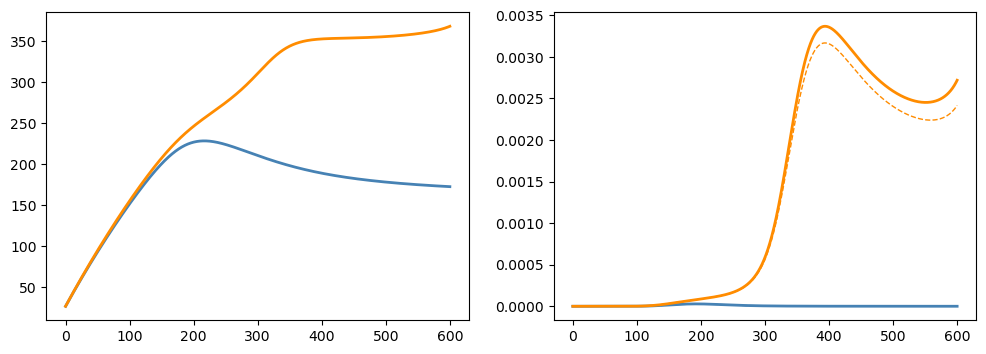

In [48]:
Tin_values  = [300.0, 600.0, 900.0]
colors_tin  = ["steelblue", "darkorange", "crimson"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for tin, col in zip(Tin_values, colors_tin):
    bc_t = build_bc_config(n_comp=nc, P_out_bar=P_out,
                           v_gas_in=V_IN, T_gas_in=tin, y_gas_in=y_air)
    par_t = {**params_base, "bc_config": bc_t}
    t_, _, g_ = run_step(sv0=sv0, t_max=T_MAX, params=par_t,
                         rtol=1e-5, atol=1e-7, n_sec=5, show_progress=False)
    lbl = f"T_in={tin:.0f} K ({tin-273.15:.0f} °C)"
    axes[0].plot(t_, g_._Ts_results[:, 0] - 273.15, color=col, lw=2, label=lbl)
    axes[1].plot(t_, g_._y_results[:, species.index("CO"), 0],  color=col, lw=2, label=f"CO {lbl}")
    axes[1].plot(t_, g_._y_results[:, species.index("H2"), 0],  color=col, lw=1, ls="--")
    print(f"  T_in={tin:.0f} K — Ts_final={g_._Ts_results[-1,0]-273.15:.0f} °C")

axes[0].set(xlabel="Tiempo [s]", ylabel="Ts [°C]", title="Temperatura del sólido")
axes[1].set(xlabel="Tiempo [s]", ylabel="Fracción molar [-]", title="CO (línea) y H₂ (trazos)")
for ax in axes: ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
fig.suptitle("11.B — Efecto del precalentamiento T_in (v_in=0.05 m/s)", fontweight="bold")
fig.tight_layout(); plt.show()

### 11.C — Tipo de agente gasificante

| Agente | Composición | Reacción dominante | Calidad del syngas |
|--------|-------------|--------------------|--------------------|
| Aire | 21 % O₂ + 79 % N₂ | Oxidación (exotérmica) | Bajo HHV — diluido con N₂ |
| Vapor | 100 % H₂O | Water-gas (endotérmica) | Alto HHV — CO + H₂ sin N₂ |
| Aire+Vapor | 21 % O₂ + 21 % H₂O + 58 % N₂ | Mixta | Equilibrio calor/calidad |

El vapor requiere energía de la pared; el aire aporta calor por oxidación.

In [ ]:
# Composiciones molares de cada agente
y_steam = np.zeros(nc); y_steam[species.index("H2O")] = 1.0
y_mix   = np.zeros(nc)
y_mix[species.index("O2")]  = 0.21
y_mix[species.index("H2O")] = 0.21
y_mix[species.index("N2")]  = 0.58

agents  = [("Aire",      y_air),  ("Vapor",     y_steam), ("Aire+Vapor", y_mix)]
colors_ag = ["darkorange", "steelblue", "forestgreen"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for (name, y_ag), col in zip(agents, colors_ag):
    bc_a = build_bc_config(n_comp=nc, P_out_bar=P_out,
                           v_gas_in=V_IN, T_gas_in=T_IN, y_gas_in=y_ag)
    par_a = {**params_base, "bc_config": bc_a}
    t_, _, g_ = run_step(sv0=sv0, t_max=T_MAX, params=par_a,
                         rtol=1e-5, atol=1e-7, n_sec=5, show_progress=False)
    axes[0].plot(t_, g_._Ts_results[:, 0] - 273.15, color=col, lw=2, label=name)
    axes[1].plot(t_, g_._rho_solid_results[:, 1, 0], color=col, lw=2, label=name)
    y_fin = g_._y_results[-1, :, 0]
    sp_show = ["CO", "CO2", "H2", "CH4", "H2O", "N2"]
    axes[2].bar([i + agents.index((name, y_ag))*0.28 for i in range(len(sp_show))],
                [y_fin[species.index(s)] for s in sp_show],
                width=0.25, color=col, label=name, alpha=0.85)
    print(f"  {name:<12} Ts={g_._Ts_results[-1,0]-273.15:.0f} °C  "
          f"rho_char={g_._rho_solid_results[-1,1,0]:.2f} kg/m3  "
          f"y_CO={y_fin[species.index('CO')]:.3f}  y_H2={y_fin[species.index('H2')]:.3f}")

axes[0].set(xlabel="Tiempo [s]", ylabel="Ts [°C]", title="Temperatura del sólido")
axes[1].set(xlabel="Tiempo [s]", ylabel="ρ_char [kg/m³_bed]", title="Conversión del char")
axes[2].set(xlabel="Especie", ylabel="Fracción molar final [-]", title="Composición gas final")
axes[2].set_xticks(range(len(sp_show))); axes[2].set_xticklabels(sp_show)
for ax in axes: ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
fig.suptitle("11.C — Tipo de agente gasificante (v_in=0.05 m/s, T_in=600 K)", fontweight="bold")
fig.tight_layout(); plt.show()

## Conclusiones

### Qué demuestra este tutorial

1. **Modo CSTR** (_gas_in > 0, _out = None): el agente gasificante fluye
   continuamente a través del lecho. La salida se regula por continuidad molar.

2. **Secuencia de reacciones acopladas**: calentamiento → drying → pirólisis →
   reacciones de char (oxidación, Boudouard, water-gas). El O₂ se consume rápidamente;
   CO, H₂ y CO₂ son los productos principales del char.

3. **Balance de especies en CSTR**: la columna Flujo [mol|kg/m³] ya no es cero.
   O₂ tiene Fuente_rxn negativa (consumido); CO y H₂ tienen Flujo positivo (salen).
   N₂ tiene Fuente_rxn ≈ 0 (inerte).

4. **v_out variable**: con continuidad molar, _out < v_in cuando las reacciones
   producen gas (Ctot_out > Ctot_in). Esto provoca acumulación y subida de presión.

5. **Agente gasificante**: el aire aporta calor por oxidación (Ts más alta) pero
   diluye el syngas con N₂. El vapor produce syngas limpio (CO+H₂) pero requiere
   energía externa; solo funciona bien con pared muy caliente.

### Qué probar a continuación

- **CSTR isobaro**: usar _out > 0 o Cv > 0 para mantener P ≈ 1 atm con flujo continuo
- **Lecho fijo 1D** (Tutorial 10): ¿qué gradientes axiales aparecen con N=10 y flujo de gas?
- **Updraft** (Tutorial 12): sólido en contracorriente con el gas — modo clásico de gasificación